# Clasificación de Géneros de Escarabajos con ResNet50

Este notebook implementa un modelo de clasificación de géneros de escarabajos usando una red neuronal convolucional preentrenada (ResNet50) y PyTorch.

## Estructura del Proyecto
- Dataset: 32 géneros de escarabajos
- Imágenes: `cropped_beetles/images_no_flash/` (solo imágenes sin flash)
- **Nota**: Se utilizan únicamente imágenes tomadas sin flash (identificadas con "_s" en el nombre)

In [12]:
# Configuración del entorno para evitar problemas de compatibilidad
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Verificar versiones instaladas
try:
    import numpy as np
    import torch
    import scipy
    import sklearn
    
    print(f"NumPy version: {np.__version__}")
    print(f"PyTorch version: {torch.__version__}")
    print(f"SciPy version: {scipy.__version__}")
    print(f"Scikit-learn version: {sklearn.__version__}")
    
    if hasattr(torch, 'cuda') and torch.cuda.is_available():
        print(f"CUDA available: {torch.cuda.is_available()}")
        print(f"CUDA version: {torch.version.cuda}")
        
    # Verificar compatibilidad de versiones
    import pkg_resources
    from packaging import version
    
    np_version = version.parse(np.__version__)
    min_np_version = version.parse("1.25.2")
    max_np_version = version.parse("2.6.0")
    
    if np_version < min_np_version or np_version >= max_np_version:
        print(f"\n⚠️ ADVERTENCIA: La versión actual de NumPy ({np.__version__}) no es compatible con SciPy.")
        print(f"   Se recomienda una versión entre 1.25.2 y 2.6.0\n")
        print("Comandos para actualizar (ejecutar en terminal):")
        print("conda activate beetles")
        print("conda install numpy=1.25.2 -y")
except ImportError as e:
    print(f"Error al importar: {e}")
    print("\nEs posible que necesites ejecutar estos comandos en una terminal:")
    print("conda activate beetles")
    print("conda install numpy=1.25.2 scipy scikit-learn -y")

NumPy version: 1.25.2
PyTorch version: 2.5.1
SciPy version: 1.16.0
Scikit-learn version: 1.7.2
CUDA available: True
CUDA version: 12.1


In [13]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score


In [14]:

# Configurar la semilla para reproducibilidad
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Verificar si GPU está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando dispositivo: {device}")

Utilizando dispositivo: cuda


📸 CARGANDO DATASET DE IMÁGENES SIN FLASH
Total de clases: 30
Total de imágenes: 2656


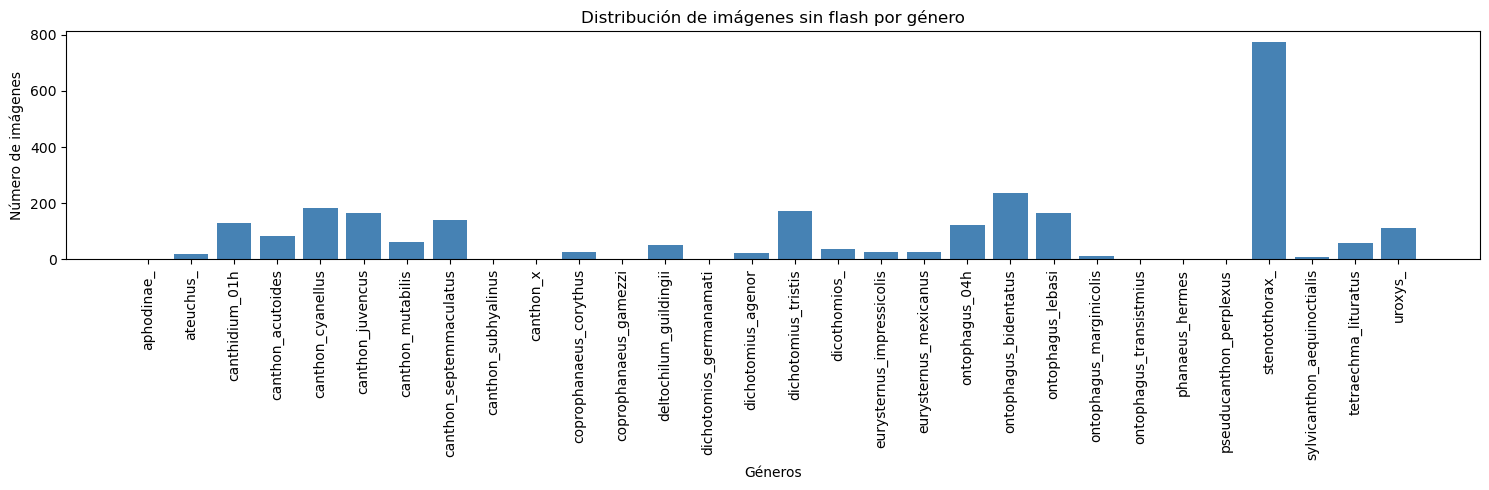

In [15]:
# Definir la clase para nuestro conjunto de datos de escarabajos
class BeetleDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Función para cargar las imágenes y etiquetas
def load_dataset(data_dir='cropped_beetles/images_no_flash'):
    image_paths = []
    labels = []
    class_names = []
    
    # Obtener las carpetas de géneros (clases)
    for class_idx, genus_folder in enumerate(sorted(os.listdir(data_dir))):
        genus_path = os.path.join(data_dir, genus_folder)
        
        if os.path.isdir(genus_path):
            class_names.append(genus_folder)
            
            # Obtener todas las imágenes de cada género
            for img_file in os.listdir(genus_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(genus_path, img_file)
                    image_paths.append(img_path)
                    labels.append(class_idx)
    
    print(f"Total de clases: {len(class_names)}")
    print(f"Total de imágenes: {len(image_paths)}")
    
    return image_paths, labels, class_names

# Cargar el dataset de imágenes SIN FLASH
print("=" * 60)
print("📸 CARGANDO DATASET DE IMÁGENES SIN FLASH")
print("=" * 60)
image_paths, labels, class_names = load_dataset('cropped_beetles/images_no_flash')

# Mostrar la distribución de clases
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(15, 5))
plt.bar([class_names[i] for i in unique_labels], counts, color='steelblue')
plt.xticks(rotation=90)
plt.xlabel('Géneros')
plt.ylabel('Número de imágenes')
plt.title('Distribución de imágenes sin flash por género')
plt.tight_layout()
plt.show()

# Definir transformaciones para preprocesamiento de imágenes
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Imágenes de entrenamiento: 2124
Imágenes de validación: 532


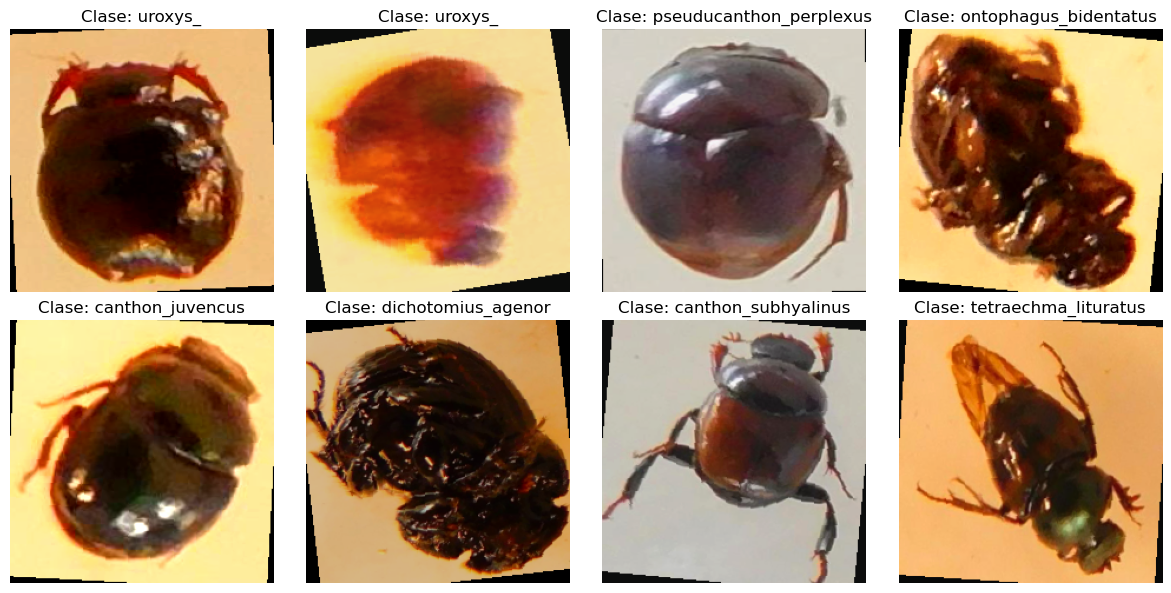

In [16]:
# Dividir los datos en conjuntos de entrenamiento y validación
# Usaremos una división estratificada para mantener la proporción de clases
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=seed, stratify=labels
)

print(f"Imágenes de entrenamiento: {len(train_paths)}")
print(f"Imágenes de validación: {len(val_paths)}")

# Calcular pesos para manejar el desbalance de clases
class_counts = np.bincount(train_labels)
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = class_weights[train_labels]

# Crear un WeightedRandomSampler para el conjunto de entrenamiento
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_labels),
    replacement=True
)

# Crear conjuntos de datos
train_dataset = BeetleDataset(train_paths, train_labels, transform=transform_train)
val_dataset = BeetleDataset(val_paths, val_labels, transform=transform_val)

# Crear data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

# Visualizar algunas imágenes de entrenamiento para verificar
def show_batch(data_loader):
    for images, labels in data_loader:
        fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
        axes = axes.flatten()
        
        for i, (img, lbl) in enumerate(zip(images[:8], labels[:8])):
            img = img.permute(1, 2, 0).numpy()
            img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
            img = np.clip(img, 0, 1)
            
            axes[i].imshow(img)
            axes[i].set_title(f'Clase: {class_names[lbl]}')
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.show()
        break

show_batch(train_loader)

In [17]:
# Crear el modelo ResNet50 preentrenado y modificar la capa final
def create_model(num_classes):
    # Cargar el modelo preentrenado
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    # Congelar todos los parámetros
    for param in model.parameters():
        param.requires_grad = False
    
    # Obtener el número de características del último layer
    num_ftrs = model.fc.in_features
    
    # Reemplazar el último layer completamente conectado
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    
    # Descongelar las últimas capas para fine-tuning
    for child in list(model.children())[-3:]:
        for param in child.parameters():
            param.requires_grad = True
            
    return model

# Crear el modelo
num_classes = len(class_names)
model = create_model(num_classes)
model = model.to(device)

# Mostrar la arquitectura del modelo
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [18]:
# Definir la función de pérdida y el optimizador
# Usamos CrossEntropyLoss con pesos de clase para manejar el desbalance
class_weights_tensor = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# Usar un planificador de tasa de aprendizaje para reducir la tasa cuando la validación se estanca
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.1, verbose=True)

# Función para entrenar el modelo
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs=100):
    # Listas para almacenar métricas de entrenamiento
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    # Mejor precisión de validación para guardar el mejor modelo
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        # Fase de entrenamiento
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Poner a cero los gradientes
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            # Backward pass y optimización
            loss.backward()
            optimizer.step()
            
            # Estadísticas
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_loss = running_loss / total
        epoch_acc = running_corrects.double() / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc.item())
        
        # Fase de validación
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        # No calcular gradientes en la validación
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                # Estadísticas
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                total += labels.size(0)
                
        val_loss = running_loss / total
        val_acc = running_corrects.double() / total
        val_losses.append(val_loss)
        val_accs.append(val_acc.item())
        
        # Paso del planificador
        scheduler.step(val_loss)
        
        # Imprimir estadísticas por época
        print(f'Época {epoch+1}/{num_epochs}: '
              f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        
        # Guardar el mejor modelo
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_beetle_model.pth')
            print(f'Nuevo mejor modelo guardado con precisión: {val_acc:.4f}')
    
    # Cargar el mejor modelo
    model.load_state_dict(torch.load('best_beetle_model.pth'))
    
    return model, train_losses, val_losses, train_accs, val_accs

# Entrenar el modelo
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, criterion, optimizer, scheduler, train_loader, val_loader
)

c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Época 1/100: Train Loss: 0.8538, Train Acc: 0.2782, Val Loss: 4.0406, Val Acc: 0.0075
Nuevo mejor modelo guardado con precisión: 0.0075
Época 2/100: Train Loss: 0.3841, Train Acc: 0.3997, Val Loss: 3.5105, Val Acc: 0.0508
Nuevo mejor modelo guardado con precisión: 0.0508
Época 2/100: Train Loss: 0.3841, Train Acc: 0.3997, Val Loss: 3.5105, Val Acc: 0.0508
Nuevo mejor modelo guardado con precisión: 0.0508
Época 3/100: Train Loss: 0.1965, Train Acc: 0.4647, Val Loss: 7.5347, Val Acc: 0.0414
Época 3/100: Train Loss: 0.1965, Train Acc: 0.4647, Val Loss: 7.5347, Val Acc: 0.0414
Época 4/100: Train Loss: 0.1347, Train Acc: 0.5433, Val Loss: 2.2084, Val Acc: 0.1259
Nuevo mejor modelo guardado con precisión: 0.1259
Época 4/100: Train Loss: 0.1347, Train Acc: 0.5433, Val Loss: 2.2084, Val Acc: 0.1259
Nuevo mejor modelo guardado con precisión: 0.1259
Época 5/100: Train Loss: 0.0875, Train Acc: 0.6266, Val Loss: 1.9671, Val Acc: 0.2274
Nuevo mejor modelo guardado con precisión: 0.2274
Época 5/100:

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_18780\3194390433.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_beetle_model.p

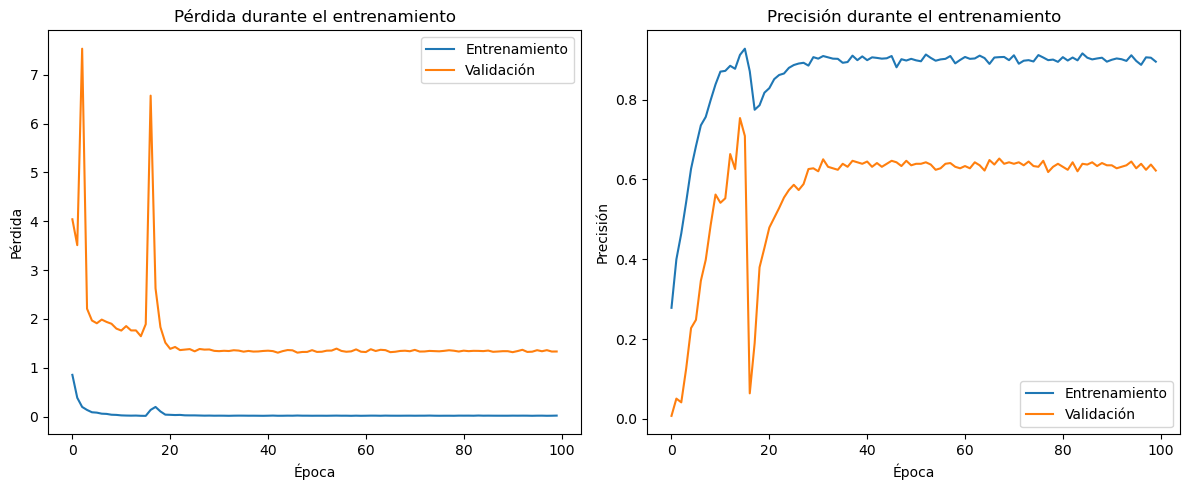

In [19]:
# Visualizar la pérdida y precisión durante el entrenamiento
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Pérdida durante el entrenamiento')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Entrenamiento')
plt.plot(val_accs, label='Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Precisión durante el entrenamiento')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Evaluar el modelo en el conjunto de validación
def evaluate_model(model, data_loader):
    model.eval()
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    return true_labels, predictions

# Obtener predicciones
true_labels, predictions = evaluate_model(model, val_loader)

# Obtener las etiquetas únicas presentes en los datos de validación
unique_labels = np.unique(true_labels)
present_class_names = [class_names[i] for i in unique_labels]

# ---


# ---

# Calcular métricas
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions, average='weighted')
recall = recall_score(true_labels, predictions, average='weighted')
f1 = f1_score(true_labels, predictions, average='weighted')

print(f"\nMétricas:")
print(f"Precisión: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(true_labels, predictions, 
                          labels=unique_labels,
                          target_names=present_class_names))


Métricas:
Precisión: 0.7538
Recall: 0.7538
F1-score: 0.7702

Reporte de clasificación:
                             precision    recall  f1-score   support

                  ateuchus_       0.50      0.50      0.50         4
             canthidium_01h       0.83      0.58      0.68        26
          canthon_acutoides       0.63      0.71      0.67        17
          canthon_cyanellus       0.97      0.86      0.91        37
           canthon_juvencus       0.61      0.85      0.71        33
          canthon_mutabilis       0.69      0.69      0.69        13
    canthon_septemmaculatus       0.93      0.93      0.93        28
     coprophanaeus_corythus       1.00      0.60      0.75         5
     deltochilum_guildingii       0.90      0.90      0.90        10
         dichotomius_agenor       1.00      1.00      1.00         5
        dichotomius_tristis       0.81      0.74      0.77        34
               dicothomios_       0.36      0.62      0.45         8
  eurysternus_

c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [48]:
metricas = classification_report(true_labels, predictions, 
                                   labels=unique_labels,
                                   target_names=present_class_names,
                                   output_dict=True)

metricas['uroxys']['precision']

c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

KeyError: 'uroxys'

📊 CLASES CON PRECISIÓN > 80%

✅ 12 clases con precisión > 80%:

1. coprophanaeus_corythus
   Precision: 100.00%
   Recall:    60.00%
   F1-Score:  0.7500
   Support:   5 imágenes

2. dichotomius_agenor
   Precision: 100.00%
   Recall:    100.00%
   F1-Score:  1.0000
   Support:   5 imágenes

3. stenotothorax_
   Precision: 100.00%
   Recall:    69.68%
   F1-Score:  0.8213
   Support:   155 imágenes

4. sylvicanthon_aequinoctialis
   Precision: 100.00%
   Recall:    50.00%
   F1-Score:  0.6667
   Support:   2 imágenes

5. canthon_cyanellus
   Precision: 96.97%
   Recall:    86.49%
   F1-Score:  0.9143
   Support:   37 imágenes

6. canthon_septemmaculatus
   Precision: 92.86%
   Recall:    92.86%
   F1-Score:  0.9286
   Support:   28 imágenes

7. ontophagus_lebasi
   Precision: 91.18%
   Recall:    93.94%
   F1-Score:  0.9254
   Support:   33 imágenes

8. deltochilum_guildingii
   Precision: 90.00%
   Recall:    90.00%
   F1-Score:  0.9000
   Support:   10 imágenes

9. eurysternus_mexica

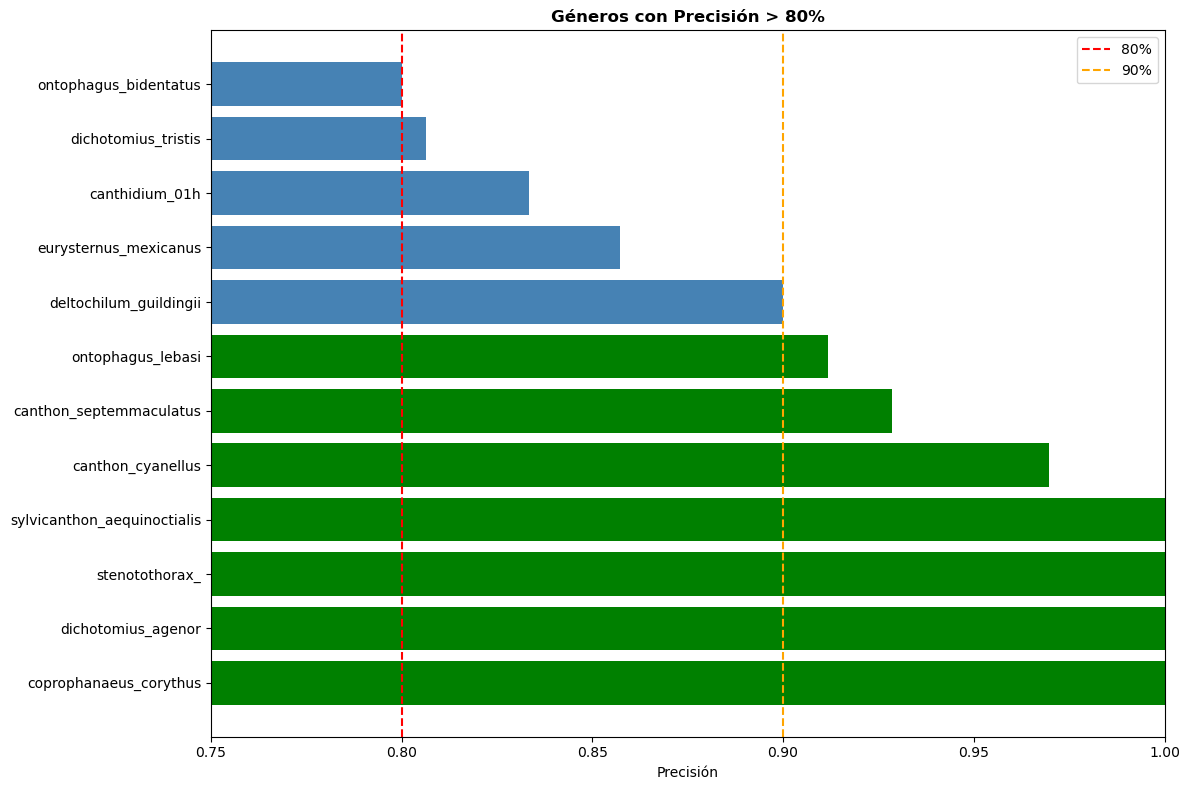

In [49]:
# Filtrar clases con precisión > 80%
print("=" * 70)
print("📊 CLASES CON PRECISIÓN > 80%")
print("=" * 70)

high_precision_classes = []

# Iterar sobre cada clase en el reporte
for class_name in present_class_names:
    if class_name in metricas:
        precision = metricas[class_name]['precision']
        recall = metricas[class_name]['recall']
        f1 = metricas[class_name]['f1-score']
        support = metricas[class_name]['support']
        
        # Filtrar solo las que tienen precisión > 80%
        if precision >= 0.80:
            high_precision_classes.append({
                'Género': class_name,
                'Precision': precision,
                'Recall': recall,
                'F1-Score': f1,
                'Support': int(support)
            })

# Ordenar por precisión descendente
high_precision_classes.sort(key=lambda x: x['Precision'], reverse=True)

# Mostrar resultados
if high_precision_classes:
    print(f"\n✅ {len(high_precision_classes)} clases con precisión > 80%:\n")
    
    for i, clase in enumerate(high_precision_classes, 1):
        print(f"{i}. {clase['Género']}")
        print(f"   Precision: {clase['Precision']*100:.2f}%")
        print(f"   Recall:    {clase['Recall']*100:.2f}%")
        print(f"   F1-Score:  {clase['F1-Score']:.4f}")
        print(f"   Support:   {clase['Support']} imágenes\n")
    
    # Crear DataFrame
    df = pd.DataFrame(high_precision_classes)
    print("\n📋 TABLA RESUMEN:")
    print(df.to_string(index=False))
    
    # Gráfico
    plt.figure(figsize=(12, 8))
    genera = [c['Género'] for c in high_precision_classes]
    precs = [c['Precision'] for c in high_precision_classes]
    colors = ['green' if p > 0.90 else 'steelblue' for p in precs]
    
    plt.barh(range(len(genera)), precs, color=colors)
    plt.yticks(range(len(genera)), genera)
    plt.xlabel('Precisión')
    plt.title('Géneros con Precisión > 80%', fontweight='bold')
    plt.axvline(x=0.80, color='red', linestyle='--', label='80%')
    plt.axvline(x=0.90, color='orange', linestyle='--', label='90%')
    plt.legend()
    plt.xlim(0.75, 1.0)
    plt.tight_layout()
    plt.show()
else:
    print("\n❌ No hay clases con precisión > 80%")

In [21]:
# Identificar clases faltantes
missing_classes = set(range(len(class_names))) - set(unique_labels)
print("\nClases faltantes en el conjunto de validación:")
for idx in missing_classes:
    print(f"- {class_names[idx]}")

# Mostrar cantidad de imágenes por clase en el conjunto original
print("\nDistribución de imágenes por clase:")
unique_all, counts_all = np.unique(labels, return_counts=True)
for idx, count in zip(unique_all, counts_all):
    print(f"{class_names[idx]}: {count} imágenes")


Clases faltantes en el conjunto de validación:
- aphodinae_
- canthon_subhyalinus
- canthon_x
- coprophanaeus_gamezzi
- dichotomios_germanamati
- phanaeus_hermes
- pseuducanthon_perplexus

Distribución de imágenes por clase:
aphodinae_: 2 imágenes
ateuchus_: 21 imágenes
canthidium_01h: 129 imágenes
canthon_acutoides: 84 imágenes
canthon_cyanellus: 183 imágenes
canthon_juvencus: 166 imágenes
canthon_mutabilis: 63 imágenes
canthon_septemmaculatus: 141 imágenes
canthon_subhyalinus: 2 imágenes
canthon_x: 2 imágenes
coprophanaeus_corythus: 25 imágenes
coprophanaeus_gamezzi: 2 imágenes
deltochilum_guildingii: 50 imágenes
dichotomios_germanamati: 2 imágenes
dichotomius_agenor: 24 imágenes
dichotomius_tristis: 171 imágenes
dicothomios_: 38 imágenes
eurysternus_impressicolis: 25 imágenes
eurysternus_mexicanus: 28 imágenes
ontophagus_04h: 124 imágenes
ontophagus_bidentatus: 237 imágenes
ontophagus_lebasi: 165 imágenes
ontophagus_marginicolis: 13 imágenes
ontophagus_transistmius: 3 imágenes
phan

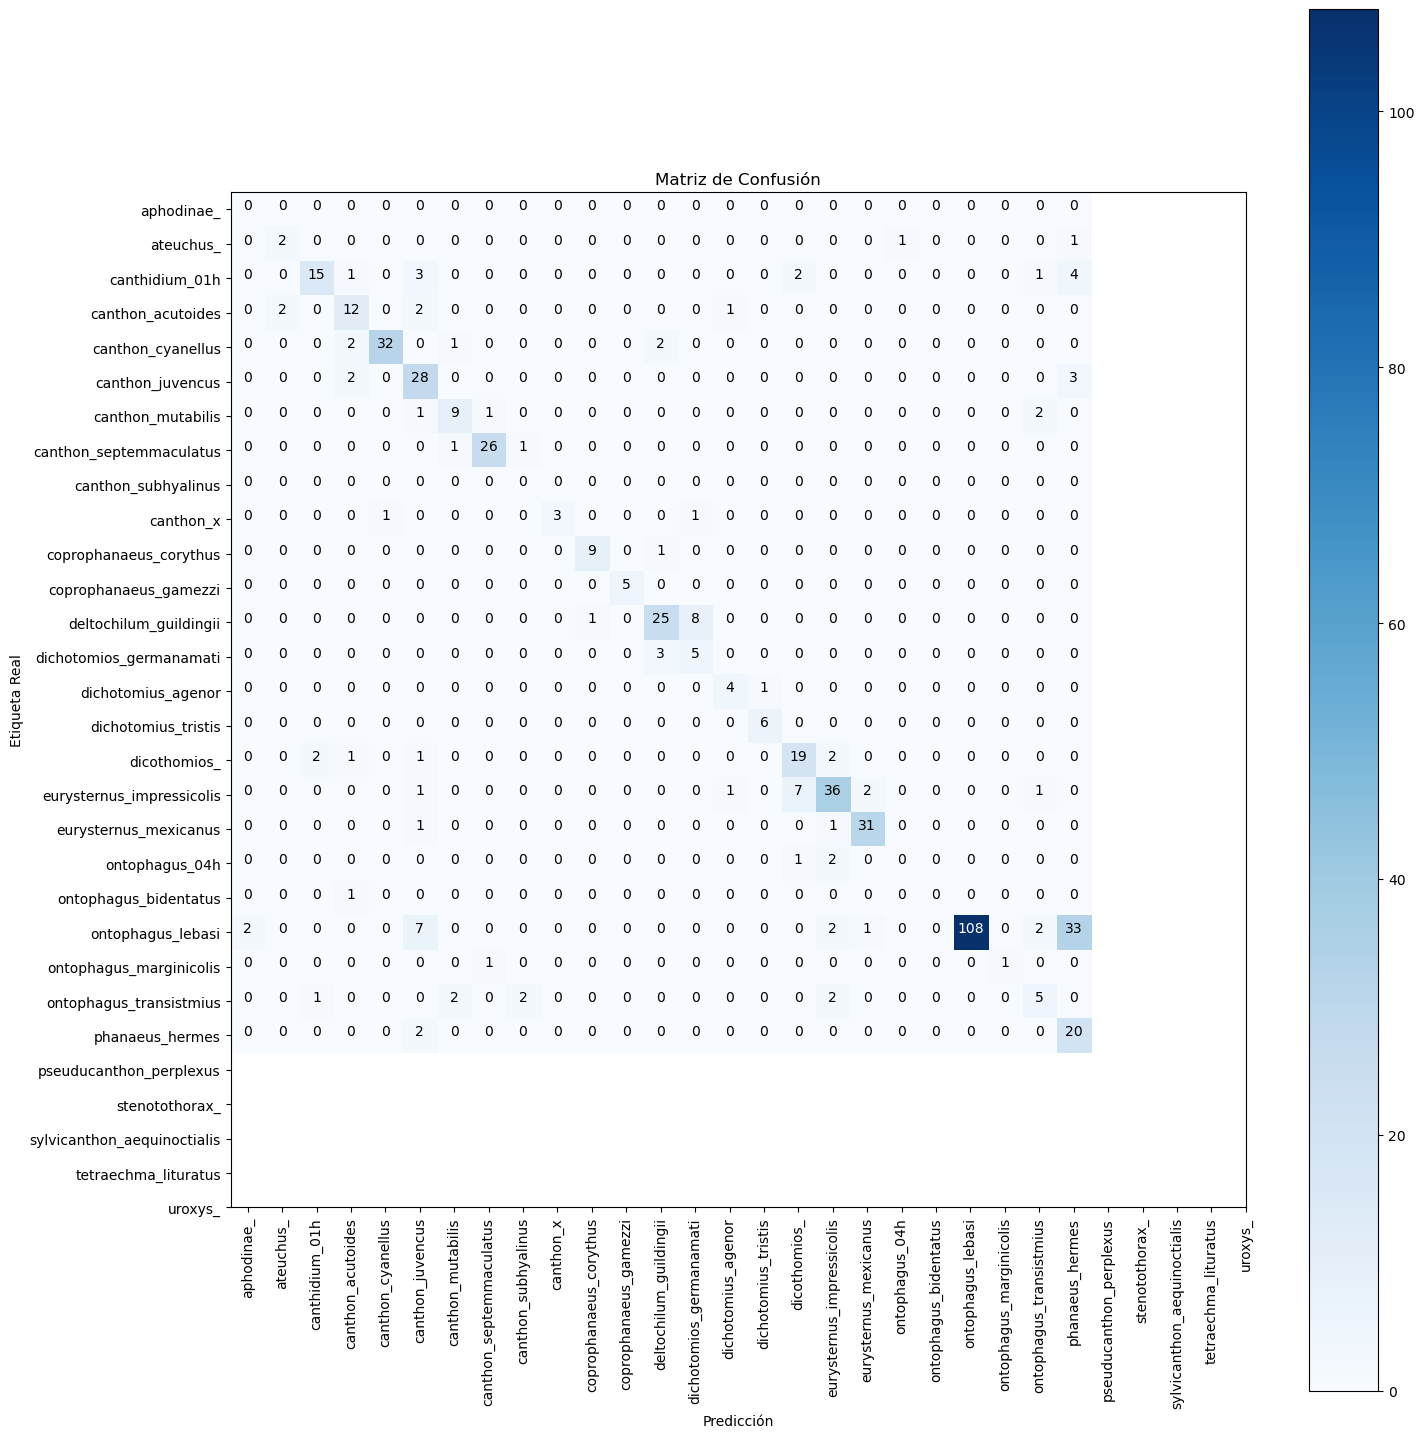

In [22]:
# Visualizar la matriz de confusión
plt.figure(figsize=(15, 15))
cm = confusion_matrix(true_labels, predictions)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()

# Etiquetas para los ejes
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

# Añadir valores numéricos a la matriz
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.show()

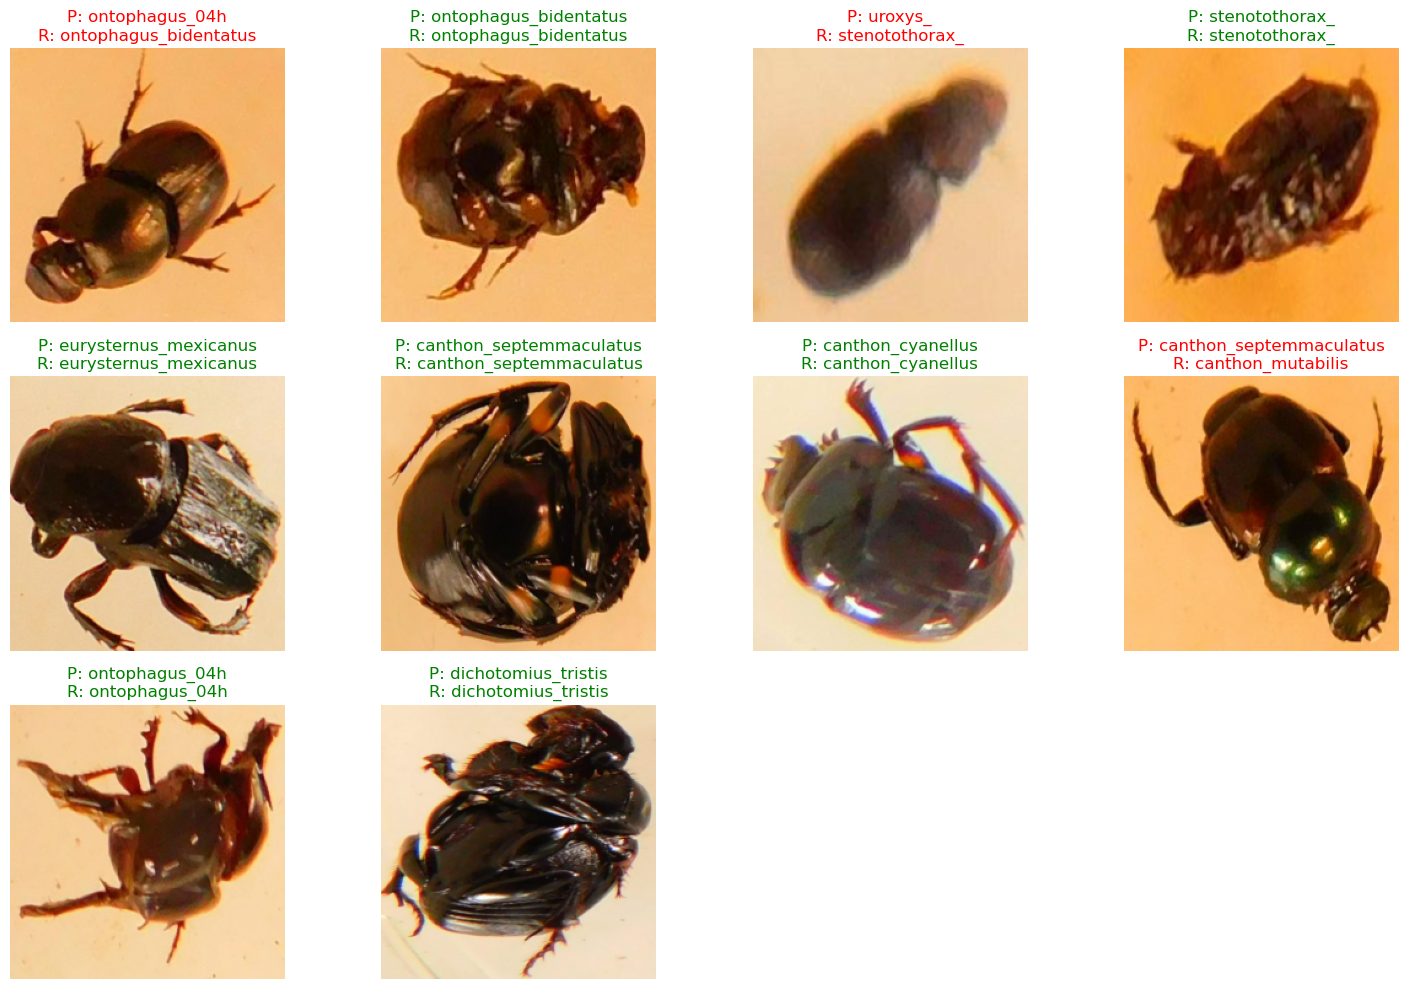

In [23]:
# Visualizar algunas predicciones en imágenes de validación
def visualize_predictions(model, data_loader, num_images=10):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(3, 4, images_so_far)
                
                # Convertir imagen de tensor a numpy para visualización
                img = inputs[j].cpu().permute(1, 2, 0).numpy()
                img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
                img = np.clip(img, 0, 1)
                
                ax.imshow(img)
                
                # Colorear el título según la predicción sea correcta o no
                color = 'green' if preds[j] == labels[j] else 'red'
                ax.set_title(f'P: {class_names[preds[j]]}\nR: {class_names[labels[j]]}', color=color)
                plt.axis('off')
                
                if images_so_far == num_images:
                    plt.tight_layout()
                    return
        
        plt.tight_layout()

# Visualizar algunas predicciones
visualize_predictions(model, val_loader)

In [24]:
# Guardar el modelo entrenado
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names': class_names
}, 'beetle_classifier_resnet50.pth')

print("Modelo guardado como 'beetle_classifier_resnet50.pth'")

Modelo guardado como 'beetle_classifier_resnet50.pth'


## Función para Predicción

A continuación se muestra cómo puedes utilizar el modelo entrenado para hacer predicciones en nuevas imágenes:

In [25]:
# Función para hacer predicciones con una nueva imagen
def predict_image(image_path, model, class_names):
    # Cargar y preprocesar la imagen
    img = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0)
    
    # Mover al dispositivo correcto
    img_tensor = img_tensor.to(device)
    
    # Modo de evaluación
    model.eval()
    
    # Hacer predicción
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        
        # Calcular probabilidades con softmax
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top_probs, top_indices = torch.topk(probabilities, 3, dim=1)
        
    # Mostrar imagen y predicciones
    plt.figure(figsize=(8, 10))
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.title(f'Predicción: {class_names[preds.item()]}')
    plt.axis('off')
    
    # Visualizar las 3 clases con mayor probabilidad
    plt.subplot(2, 1, 2)
    top_probs = top_probs.squeeze().cpu().numpy()
    top_indices = top_indices.squeeze().cpu().numpy()
    
    top_classes = [class_names[i] for i in top_indices]
    
    plt.barh(range(3), top_probs, color='skyblue')
    plt.yticks(range(3), top_classes)
    plt.xlabel('Probabilidad')
    plt.title('Top 3 Predicciones')
    plt.tight_layout()
    plt.show()
    
    return preds.item(), probabilities.squeeze().cpu().numpy()

# Ejemplo de cómo usar la función de predicción (descomenta para probar)
# nueva_imagen = "ruta/a/nueva/imagen.jpg"
# pred_class, probabilities = predict_image(nueva_imagen, model, class_names)